In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
np.random.seed(42)

**Сгенирируем признаки**

In [47]:
X, y, true_coef = make_regression(
    n_samples=2000,
    n_features=5,
    n_informative=5,
    shuffle=True,
    coef=True,
    random_state=42,
    noise=15
)

In [48]:
print(f"  Среднее:      {np.mean(y):.4f}")
print(f"  Медиана:      {np.median(y):.4f}")
print(f"  Станд. откл.: {np.std(y):.4f}")
print(f"  Мин:          {np.min(y):.4f}")
print(f"  Макс:         {np.max(y):.4f}")
print(f"  Размах:       {np.max(y) - np.min(y):.4f}")

  Среднее:      0.7264
  Медиана:      1.1321
  Станд. откл.: 69.0233
  Мин:          -293.1907
  Макс:         262.4979
  Размах:       555.6886


**Добавляем столбец единиц к матрице признаков X для того, чтобы модель смогла обучить свободный член**

In [49]:
X = np.column_stack([X,np.ones(2000)])

**Искуственно масштабируем признаки**

In [50]:
scales = [1, 10, 1000, 0.1, 0.01]
X[:, :-1] = X[:, :-1] * scales

**Приводим все признаки к одному масштабу: mean=0, std=1**

**Это необходимо для корректной работы градиентного спуска**

In [51]:
mean = X[:, :-1].mean(axis=0)
std = X[:, :-1].std(axis=0)
x_norm = X.copy()
x_norm[:, :-1] = (X[:, :-1] - mean) / std

**Разделим дата сет на тренировочную и тестовую выборки**

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x_norm, y, test_size=0.2)
y_train= y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
y = y.reshape(-1,1)

In [53]:
w = np.random.randn(X_train.shape[1]) * 0.01
w = w.reshape(-1,1)

**Напиши функцию для подсчета MSE и градиента MSE**

In [54]:
def mse(X, y, w):
    return np.mean((X @ w - y) ** 2) / 2

def grad_MSE(X, y, w):
    return X.T @ (X @ w - y) / len(X)

**Тестируем разные lr, чтобы найти оптимальный**


**Строим графики сходимости для визуального сравнения**

Количество итераций:  1999
learning_rate: 0.001
[[28.65022721  8.06563412  8.69958653 49.03194063  6.81960524  0.62886902]]

Количество итераций:  1999
learning_rate: 0.003
[[33.27903566  9.34462995 10.6329233  56.75066623  7.73909376  0.72466571]]

Количество итераций:  1368
learning_rate: 0.01
[[33.37431987  9.37062214 10.68965709 56.90130937  7.75284559  0.72643773]]

Количество итераций:  489
learning_rate: 0.03
[[33.37435507  9.37063194 10.68968612 56.90135962  7.75284892  0.72643825]]

Количество итераций:  154
learning_rate: 0.1
[[33.37436759  9.37063545 10.68969683 56.90137719  7.75285005  0.72643843]]



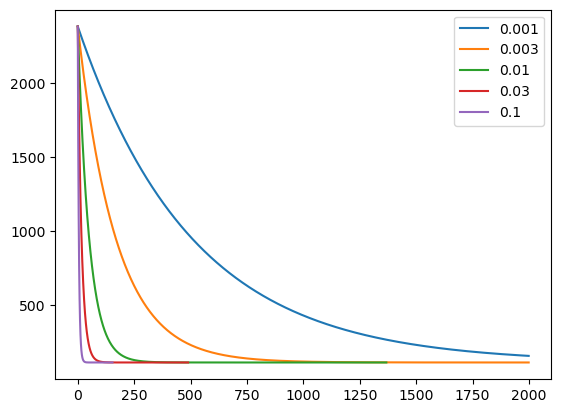

In [55]:
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]

eps = 0.000001

max_iter = 2000


for ind in range(len(learning_rates)):

  next_w = w
  mse_ls = []

  for i in range(max_iter):

    cur_w = next_w

    next_w = cur_w - learning_rates[ind] * grad_MSE(x_norm,y,cur_w)
    mse_ls.append(mse(x_norm,y,cur_w))
    if np.linalg.norm(cur_w - next_w, ord=2) <= eps:
        break
  sns.lineplot(x=np.arange(0,i+1),y=mse_ls,label=f'{learning_rates[ind]}')
  print('Количество итераций: ',i)
  print(f"learning_rate: {learning_rates[ind]}")
  print(next_w.reshape(1,-1))
  print()

**Класс-обертка для обучения модели и вывода метрик**

In [56]:
class model:

    learning_rates = 0.1
    eps = 0.000001
    max_iter = 500


    def __init__(self):

        self.w = None

    def MSE(self, X, y):
        if self.w is None:
          raise ValueError("Модель не обучена")

        return np.mean((X @ self.w - y) ** 2) / 2

    def grad_MSE(self, X, y, w):
      return X.T @ (X @ w - y) / len(X)

    def RMSE(self,X,y):
      if self.w is None:
          raise ValueError("Модель не обучена")
      return np.sqrt(np.mean((X @ self.w - y) ** 2) / 2)

    def MAE(self,X,y):
      if self.w is None:
          raise ValueError("Модель не обучена")

      return np.mean(np.abs((X @ self.w - y)))

    def MAPE(self,X,y):
          if self.w is None:
              raise ValueError("Модель не обучена")
          return np.mean(np.abs((y - X @ self.w) / y[y != 0])) * 100
    
    def R2(self,X,y):
        if self.w is None:
            raise ValueError("Модель не обучена")
        vr = np.var(y)
        ms = self.MSE(X,y)
        return 1 - (ms/vr)
    def learn(self, X, y):
        next_w = np.random.randn(X.shape[1]) * 0.01
        next_w = next_w.reshape(-1,1)

        for i in range(self.max_iter):

            cur_w = next_w

            next_w = cur_w - self.learning_rates * self.grad_MSE(X, y, cur_w)


            if np.linalg.norm(cur_w - next_w, ord=2) <= self.eps:
                break

        self.w = next_w

    def predict(self,X):
      if self.w is None:
            raise ValueError("Модель не обучена")
      return  X @ self.w

    def print_metrics_compact(self, X, y):
      print(f"MSE: {self.MSE(X, y):.4f}")
      print(f"RMSE: {self.RMSE(X, y):.4f}")
      print(f"MAE:  {self.MAE(X, y):.4f}")
      print(f"MAPE: {self.MAPE(X, y):.2f}%")
      print(f"R2: {self.R2(X, y):.2f}%")

**Обучим модель**

In [57]:
mod = model()
mod.learn(X_train,y_train)
y_t = mod.predict(X_test)

In [58]:
mod.print_metrics_compact(X_train,y_train)

MSE: 117.1893
RMSE: 10.8254
MAE:  12.1811
MAPE: 123.58%
R2: 0.98%


In [59]:
mod.print_metrics_compact(X_test,y_test)

MSE: 101.4099
RMSE: 10.0702
MAE:  11.1085
MAPE: 93.61%
R2: 0.98%


**Вывод:** MAPE — неинформативен из-за наличия отрицательных    и близких к нулю значений в целевой переменной. Также заметим, что метрика R2 на обучающей и тестовой выборке соввпадают, что значит отсутствие переобучение у модели.

In [60]:
mod_sk = LinearRegression(fit_intercept=False)
mod_sk.fit(X_train,y_train)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Сравним полученные веса модели с весами модели из библиотеки sklear**

In [61]:
print((mod.w).reshape(-1))

[33.14316664  9.52207066 10.72951467 56.72976707  7.80023183  0.92586811]


In [62]:
print((mod_sk.coef_).reshape(-1))

[33.14317248  9.52207252 10.72951852 56.72977216  7.80023208  0.92586758]
